[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLOv8 Object Detection on a Custom Dataset

---

[![Roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/how-to-train-yolov8-on-a-custom-dataset)
[![YouTube](https://badges.aleen42.com/src/youtube.svg)](https://youtu.be/wuZtUMEiKWY)
[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/ultralytics/ultralytics)

Ultralytics YOLOv8 is a popular version of the YOLO (You Only Look Once) object detection and image segmentation model developed by Ultralytics. The YOLOv8 model is designed to be fast, accurate, and easy to use, making it an excellent choice for a wide range of object detection and image segmentation tasks. It can be trained on large datasets and is capable of running on a variety of hardware platforms, from CPUs to GPUs.

## Disclaimer

If you notice that our notebook behaves incorrectly - especially if you experience errors that prevent you from going through the tutorial - don't hesitate! Let us know and open an [issue](https://github.com/roboflow/notebooks/issues) on the Roboflow Notebooks repository.

## Accompanying Blog Post

We recommend that you follow along in this notebook while reading the accompanying [Blog Post](https://blog.roboflow.com/how-to-train-yolov8-on-a-custom-dataset/).

## Pro Tip: Use GPU Acceleration

If you are running this notebook in Google Colab, navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`. This will ensure your notebook uses a GPU, which will significantly speed up model training times.

## Steps in this Tutorial

In this tutorial, we are going to cover:

- Before you start
- Install YOLOv8
- CLI Basics
- Inference with Pre-trained COCO Model
- Roboflow Universe
- Preparing a custom dataset
- Custom Training
- Validate Custom Model
- Inference with Custom Model

**Let's begin!**

## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Mon Nov  3 14:32:00 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLOv8

YOLOv8 can be installed in two ways - from the source and via pip. This is because it is the first iteration of YOLO to have an official package.

In [3]:
# Pip install method (recommended)

!pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output()

# prevent ultralytics from tracking your activity
!yolo settings sync=False

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.103 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.5/112.6 GB disk)


In [4]:
from ultralytics import YOLO

from IPython.display import display, Image

## CLI Basics

If you want to train, validate or run inference on models and don't need to make any modifications to the code, using YOLO command line interface is the easiest way to get started. Read more about CLI in [Ultralytics YOLO Docs](https://docs.ultralytics.com/usage/cli/).

```
yolo task=detect    mode=train    model=yolov8n.yaml      args...
          classify       predict        yolov8n-cls.yaml  args...
          segment        val            yolov8n-seg.yaml  args...
                         export         yolov8n.pt        format=onnx  args...
```

## Inference with Pre-trained COCO Model

### 💻 CLI

`yolo mode=predict` runs YOLOv8 inference on a variety of sources, downloading models automatically from the latest YOLOv8 release, and saving results to `runs/predict`.

In [5]:
%cd {HOME}
!yolo task=detect mode=predict model=yolov8n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=True

/content
100% 6.25M/6.25M [00:00<00:00, 263MB/s]
Ultralytics YOLOv8.2.103 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n summary (fused): 168 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

100% 104k/104k [00:00<00:00, 74.2MB/s]
image 1/1 /content/dog.jpeg: 640x384 1 person, 1 car, 1 dog, 42.8ms
Speed: 2.6ms preprocess, 42.8ms inference, 382.7ms postprocess per image at shape (1, 3, 640, 384)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


/content


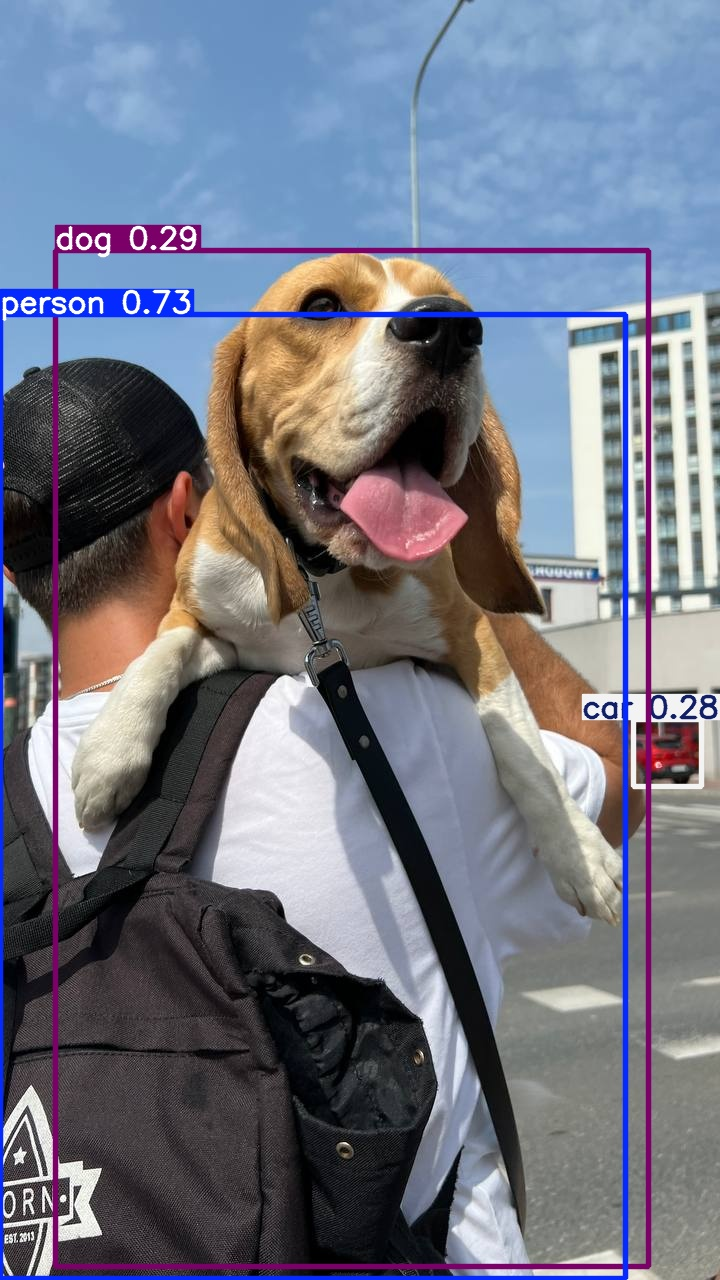

In [6]:
%cd {HOME}
Image(filename='runs/detect/predict/dog.jpeg', height=600)

### 🐍 Python SDK

The simplest way of simply using YOLOv8 directly in a Python environment.

In [ ]:
model = YOLO(f'{HOME}/yolov8n.pt')
results = model.predict(source='https://media.roboflow.com/notebooks/examples/dog.jpeg', conf=0.25)


Found https://media.roboflow.com/notebooks/examples/dog.jpeg locally at dog.jpeg
image 1/1 /content/dog.jpeg: 640x384 1 person, 1 car, 1 dog, 82.0ms
Speed: 3.4ms preprocess, 82.0ms inference, 1081.0ms postprocess per image at shape (1, 3, 640, 384)


In [ ]:
results[0].boxes.xyxy

tensor([[   0.0000,  314.4717,  625.0754, 1278.1946],
        [  55.1731,  250.0220,  648.1080, 1266.2720],
        [ 633.2291,  719.5391,  701.0538,  786.0336]], device='cuda:0')

In [ ]:
results[0].boxes.conf

tensor([0.7271, 0.2907, 0.2846], device='cuda:0')

In [ ]:
results[0].boxes.cls

tensor([ 0., 16.,  2.], device='cuda:0')

## Roboflow Universe

Need data for your project? Before spending time on annotating, check out Roboflow Universe, a repository of more than 110,000 open-source datasets that you can use in your projects. You'll find datasets containing everything from annotated cracks in concrete to plant images with disease annotations.


[![Roboflow Universe](https://media.roboflow.com/notebooks/template/uni-banner-frame.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672878480290)](https://universe.roboflow.com/)



## Preparing a custom dataset

Building a custom dataset can be a painful process. It might take dozens or even hundreds of hours to collect images, label them, and export them in the proper format. Fortunately, Roboflow makes this process as straightforward and fast as possible. Let me show you how!

### Step 1: Creating project

Before you start, you need to create a Roboflow [account](https://app.roboflow.com/login). Once you do that, you can create a new project in the Roboflow [dashboard](https://app.roboflow.com/). Keep in mind to choose the right project type. In our case, Object Detection.

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/creating-project.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1672929799852"
  >
</div>

### Step 2: Uploading images

Next, add the data to your newly created project. You can do it via API or through our [web interface](https://docs.roboflow.com/adding-data/object-detection).

If you drag and drop a directory with a dataset in a [supported format](https://roboflow.com/formats), the Roboflow dashboard will automatically read the images and annotations together.

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/uploading-images.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1672929808290"
  >
</div>

### Step 3: Labeling

If you only have images, you can label them in [Roboflow Annotate](https://docs.roboflow.com/annotate).

<div align="center">
  <img
    width="640"
    src="https://user-images.githubusercontent.com/26109316/210901980-04861efd-dfc0-4a01-9373-13a36b5e1df4.gif"
  >
</div>

### Step 4: Generate new dataset version

Now that we have our images and annotations added, we can Generate a Dataset Version. When Generating a Version, you may elect to add preprocessing and augmentations. This step is completely optional, however, it can allow you to significantly improve the robustness of your model.

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/generate-new-version.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1673003597834"
  >
</div>

### Step 5: Exporting dataset

Once the dataset version is generated, we have a hosted dataset we can load directly into our notebook for easy training. Click `Export` and select the `YOLO v8` dataset format. (Formerly, we used to use `Yolov5`, as the gif shows)

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/export.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1672943313709"
  >
</div>




🟢 Tip: The examples below work even if you use our non-custom model. However, you won't be able to deploy it to Roboflow. To do that, create a custom dataset as described below or fork (copy) one into your workspace from Universe.

In [7]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="FkHiEppTDaEjEzlke8oA")
project = rf.workspace("shaheen-pktgs").project("shoplifting-yefyu-eo7hq")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 97.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to shoplifting-1 in yolov8:: 100%|██████████| 16802/16802 [00:01<00:00, 9611.28it/s] 


## Custom Training

In [9]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=10 imgsz=800 plots=True

/content
New https://pypi.org/project/ultralytics/8.3.223 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/shoplifting-1/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=800, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, s

/content


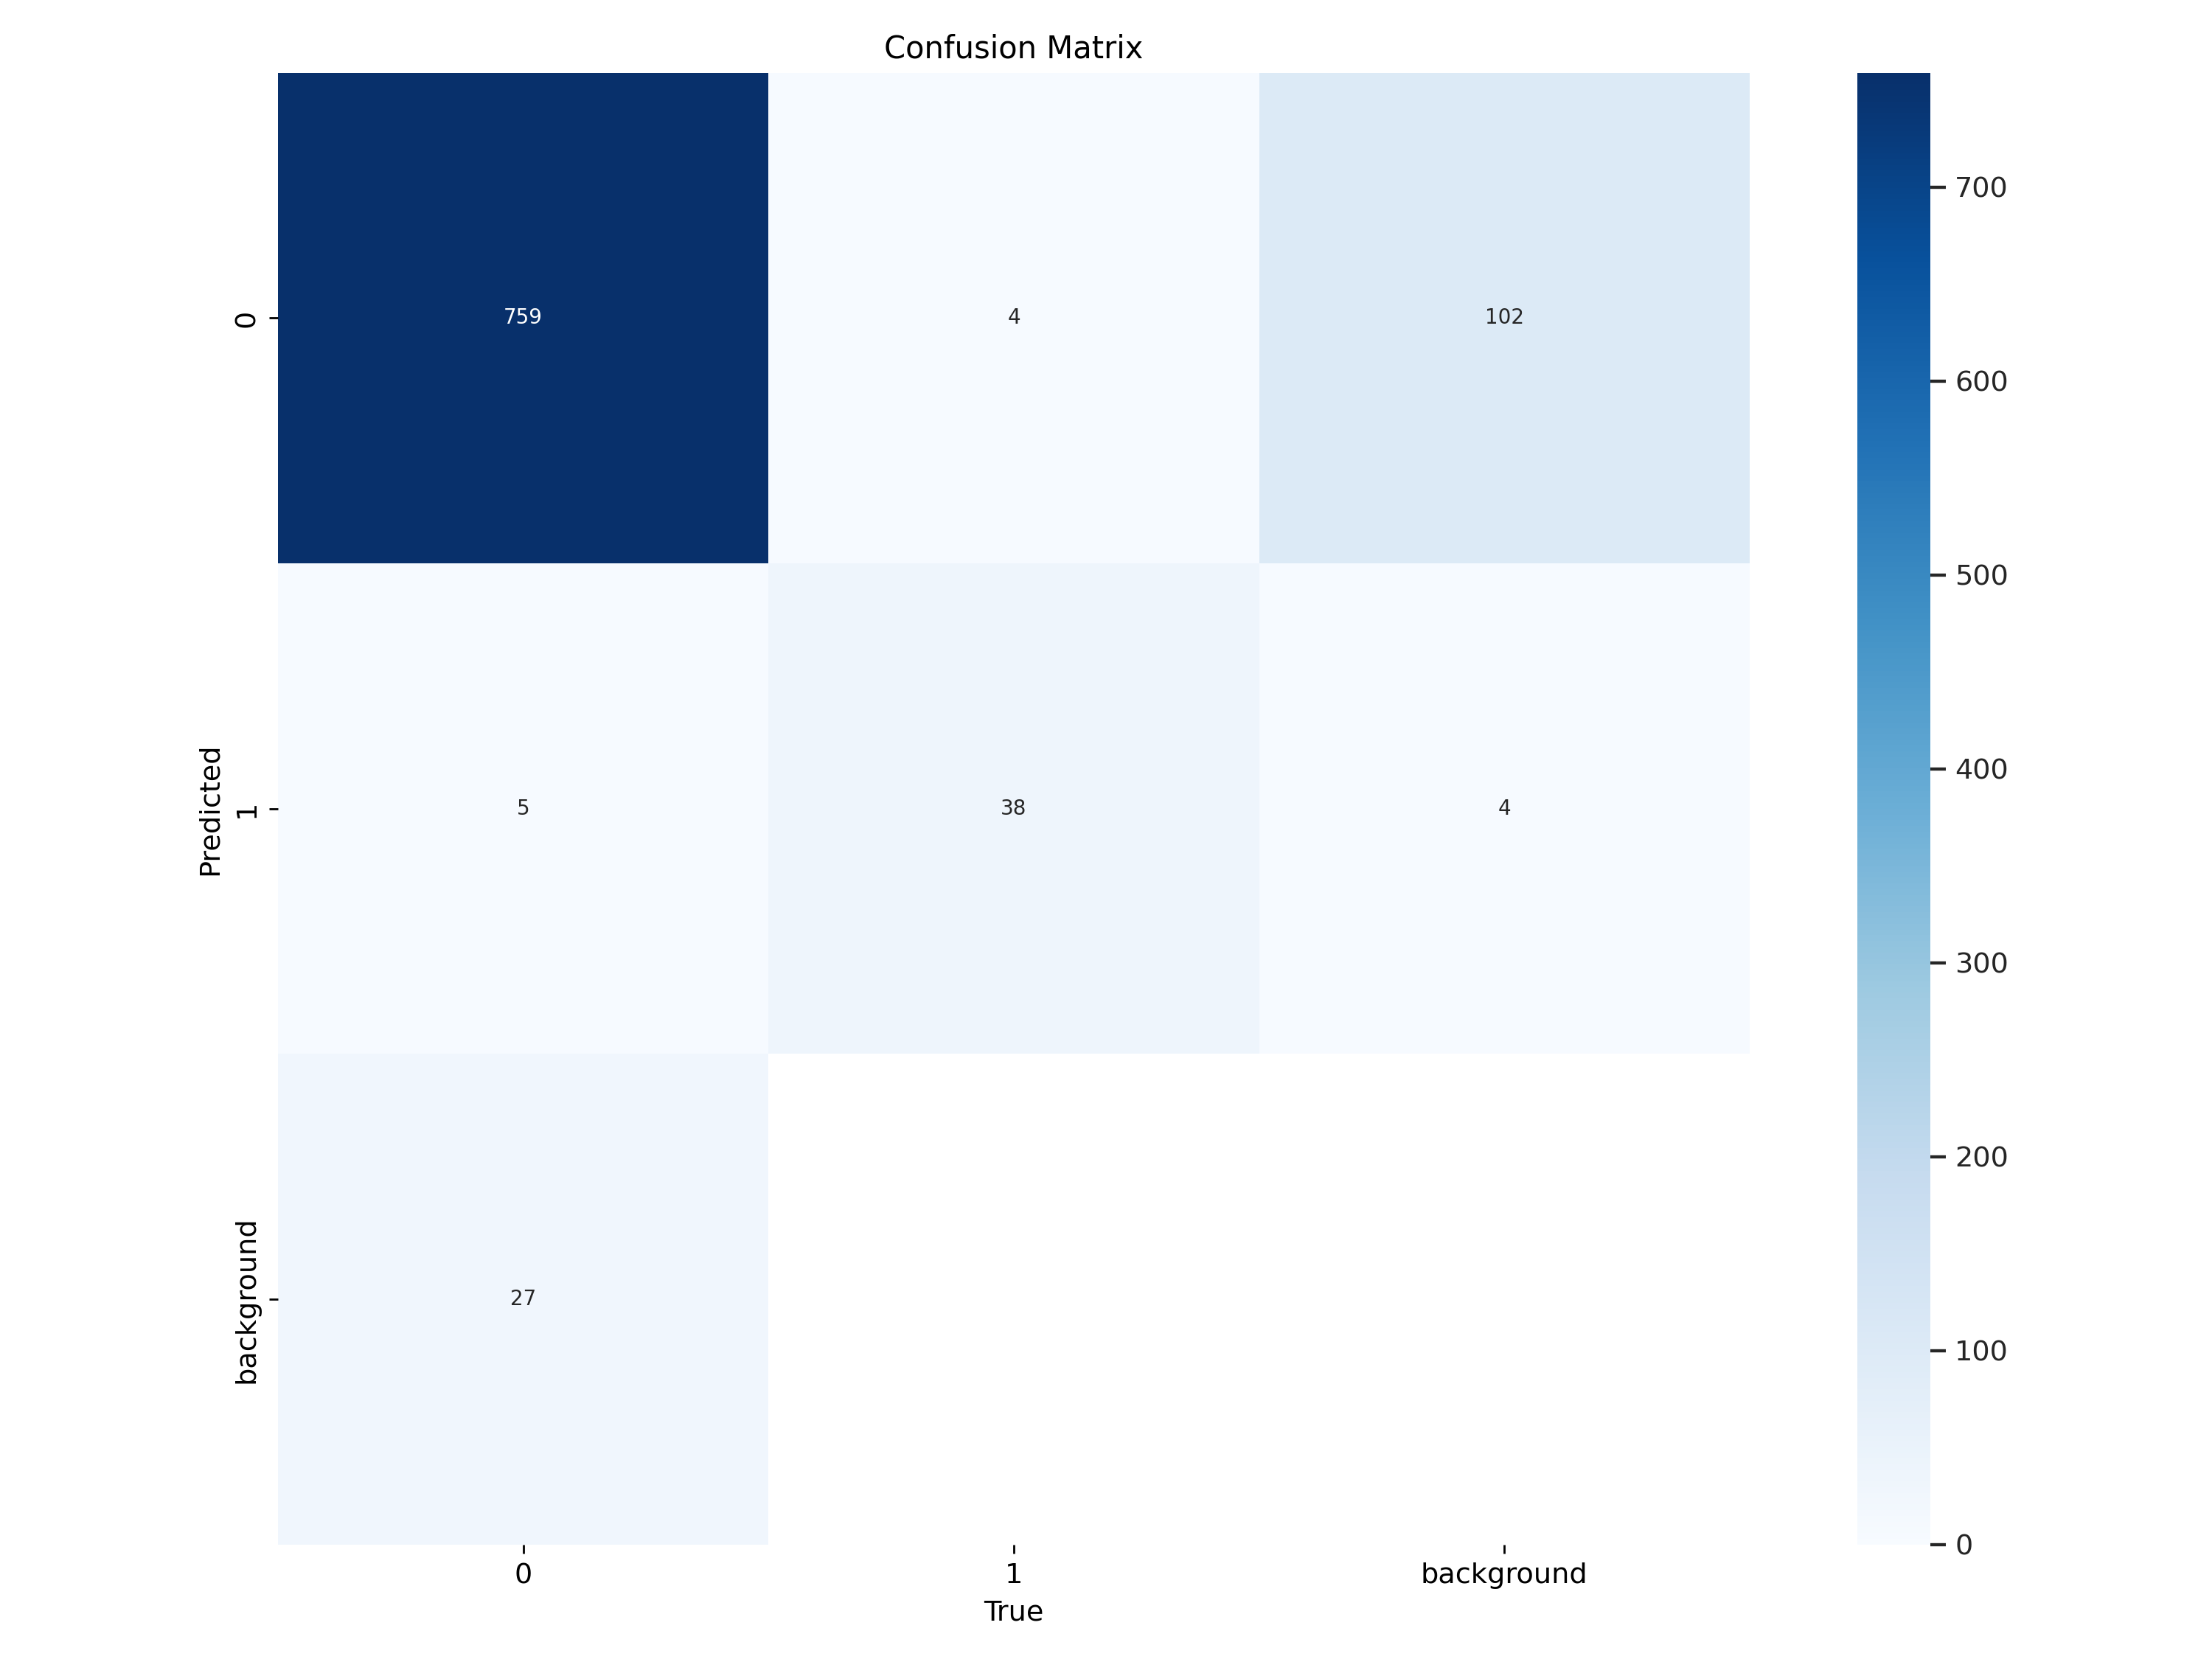

In [14]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train2/confusion_matrix.png', width=600)

/content


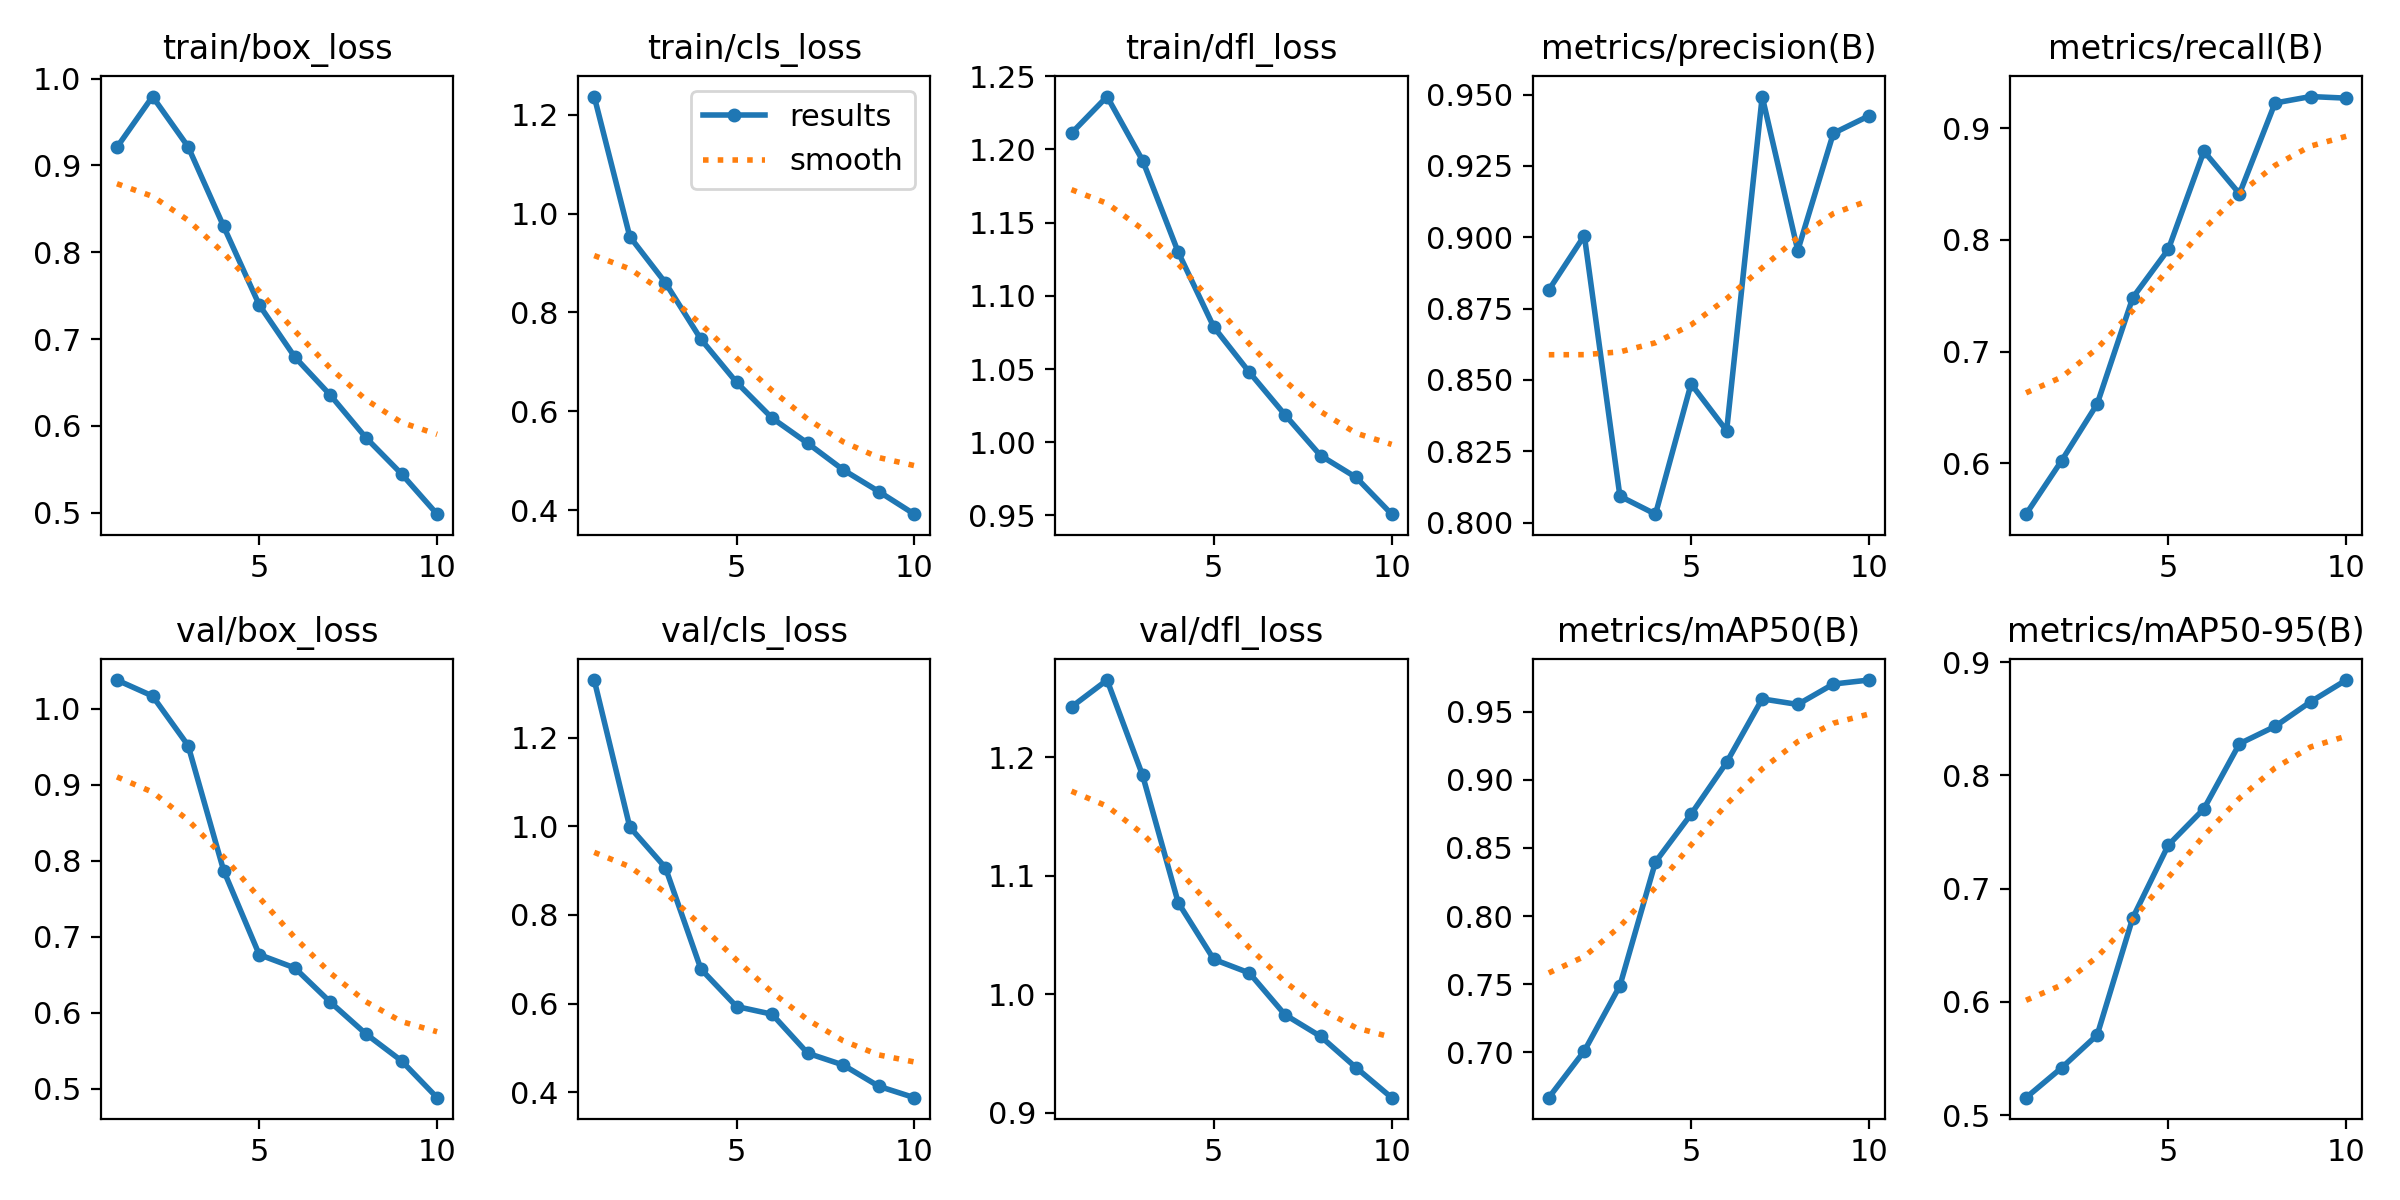

In [15]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train2/results.png', width=600)

/content


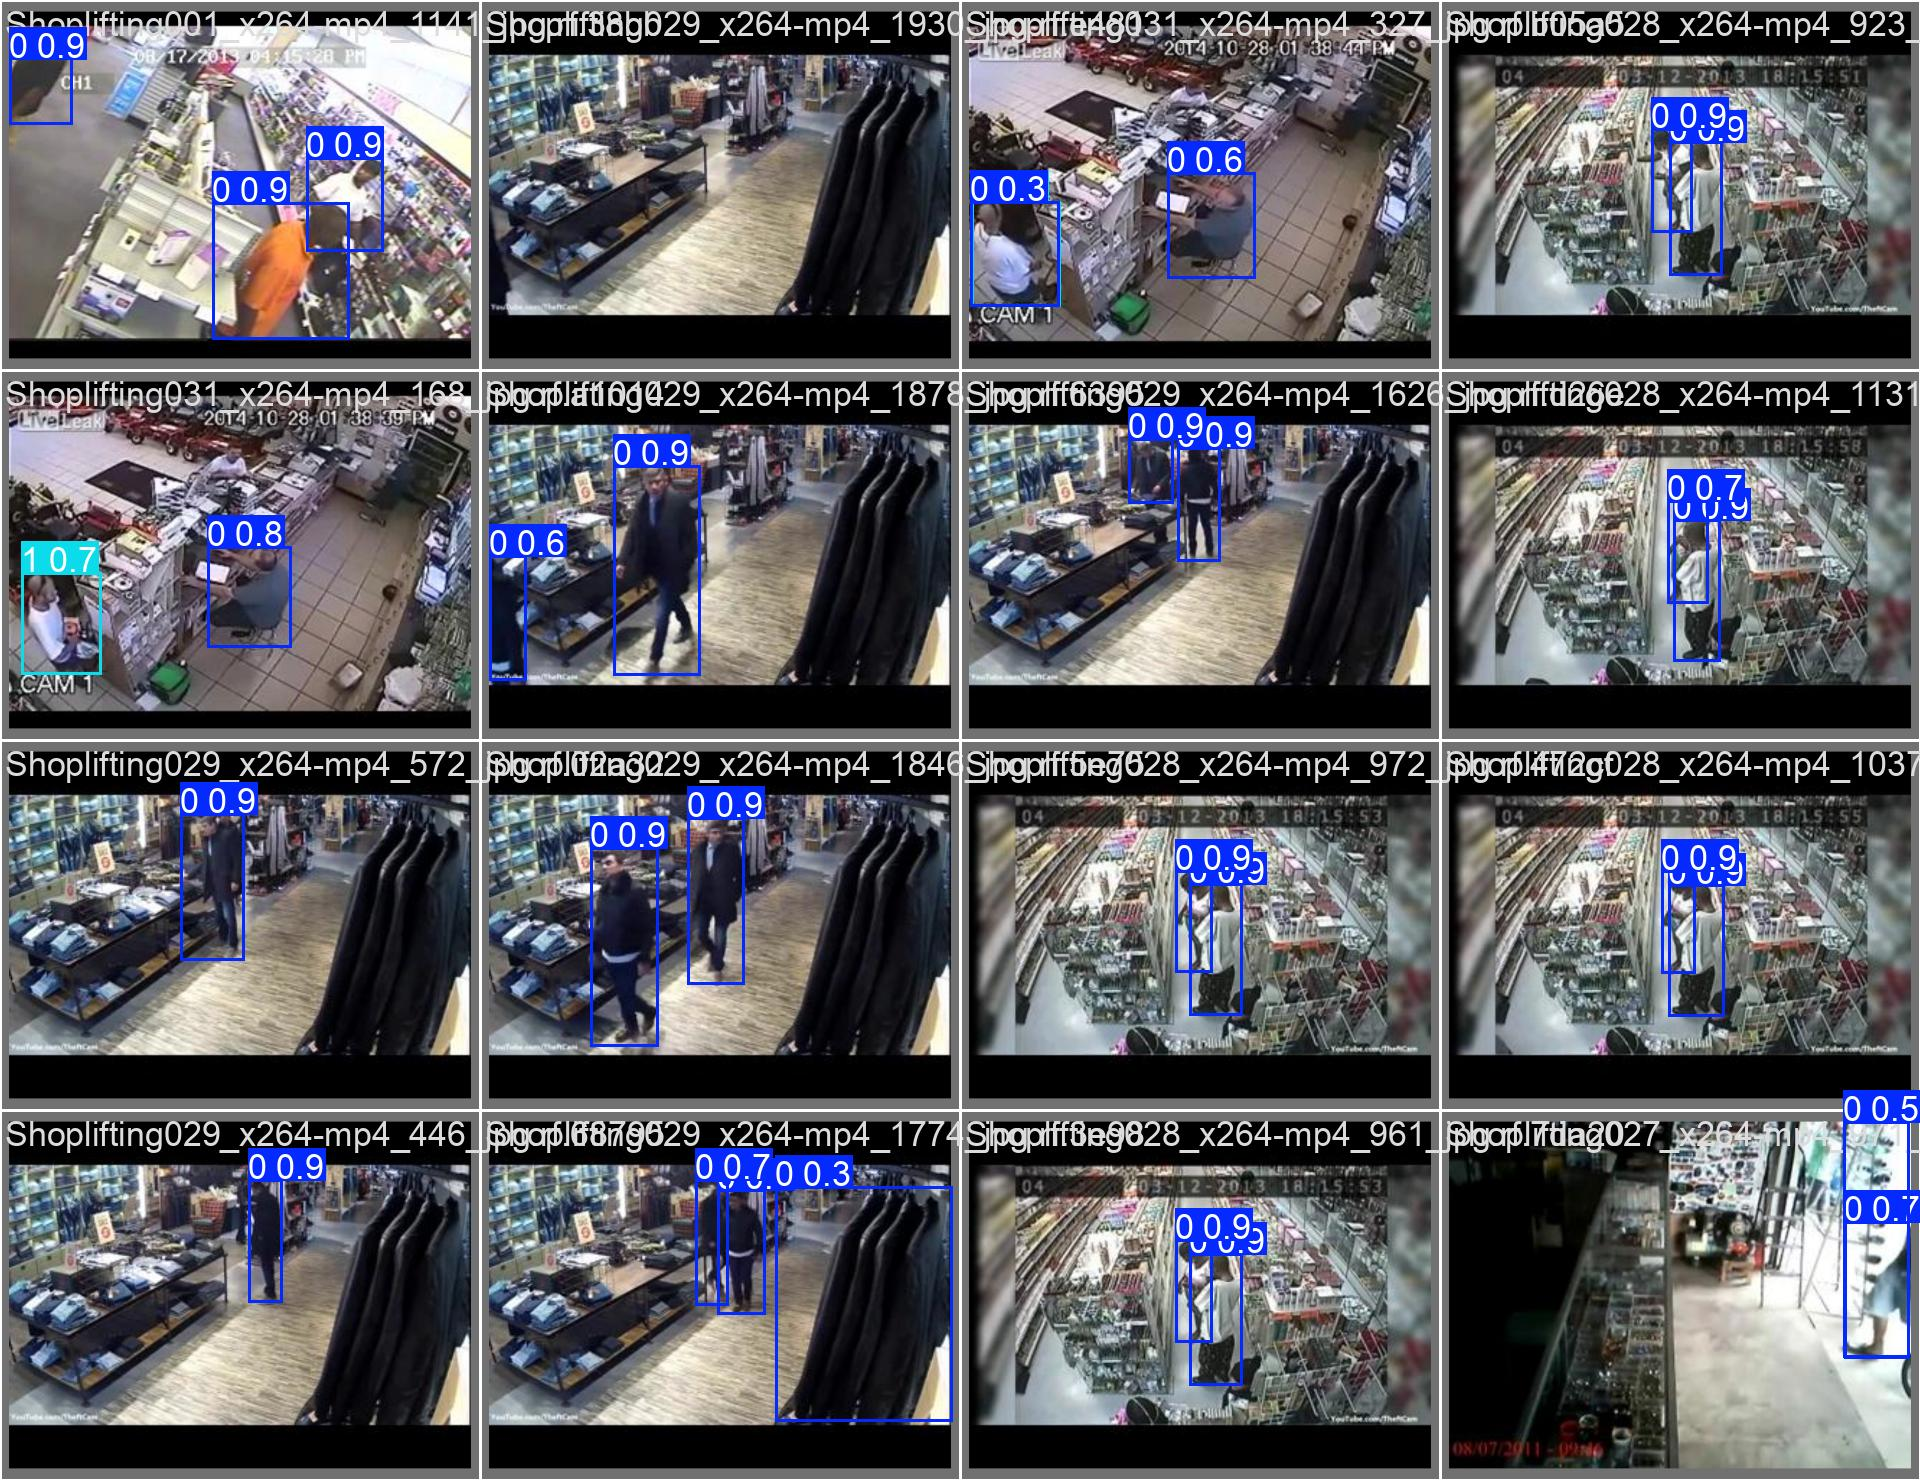

In [16]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train2/val_batch0_pred.jpg', width=600)

## Validate Custom Model

In [18]:
%cd {HOME}

!yolo task=detect mode=val model={HOME}/runs/detect/train2/weights/best.pt data={dataset.location}/data.yaml

/content
Ultralytics YOLOv8.2.103 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Scanning /content/shoplifting-1/valid/labels.cache... 334 images, 0 backgrounds, 0 corrupt: 100% 334/334 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 21/21 [00:05<00:00,  3.68it/s]
                   all        334        833      0.943      0.927      0.973      0.886
                     0        322        791      0.943      0.901      0.975      0.876
                     1         37         42      0.942      0.952      0.972      0.895
Speed: 1.5ms preprocess, 9.9ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


## Inference with Custom Model

In [19]:
%cd {HOME}
!yolo task=detect mode=predict model={HOME}/runs/detect/train2/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

/content
Ultralytics YOLOv8.2.103 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

image 1/280 /content/shoplifting-1/test/images/Shoplifting001_x264-mp4_1241_jpg.rf.2d16e73885ba56b0c507be185450ced9.jpg: 608x800 3 0s, 42.1ms
image 2/280 /content/shoplifting-1/test/images/Shoplifting001_x264-mp4_1367_jpg.rf.5283c414fa97151f2963447953c12110.jpg: 608x800 2 0s, 18.2ms
image 3/280 /content/shoplifting-1/test/images/Shoplifting001_x264-mp4_1791_jpg.rf.d90c04c1445c7dd4672a4470402b69f1.jpg: 608x800 4 0s, 18.1ms
image 4/280 /content/shoplifting-1/test/images/Shoplifting001_x264-mp4_2019_jpg.rf.e4365e840ea45b4b7cae3f93a6b7f1db.jpg: 608x800 2 0s, 18.1ms
image 5/280 /content/shoplifting-1/test/images/Shoplifting001_x264-mp4_2417_jpg.rf.c16e14380964f79455fa1501629a07d3.jpg: 608x800 1 0, 18.1ms
image 6/280 /content/shoplifting-1/test/images/Shoplifting001_x264-mp4_3039_jpg.rf.7b945b9afd4eecd325fc5d922e0

**NOTE:** Let's take a look at few results.

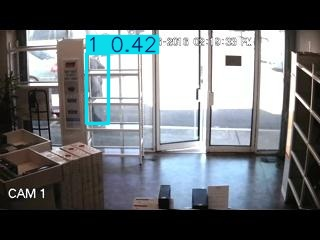

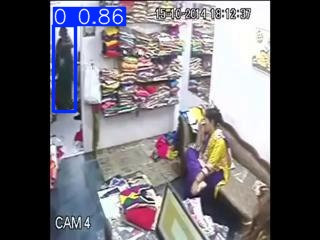

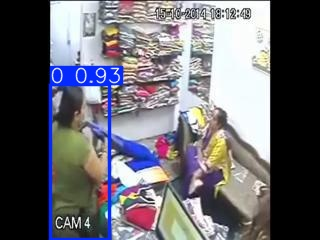

In [20]:
import glob
from IPython.display import Image, display

# Define the base path where the folders are located
base_path = '/content/runs/detect/'

# List all directories that start with 'predict' in the base path
subfolders = [os.path.join(base_path, d) for d in os.listdir(base_path)
              if os.path.isdir(os.path.join(base_path, d)) and d.startswith('predict')]

# Find the latest folder by modification time
latest_folder = max(subfolders, key=os.path.getmtime)

image_paths = glob.glob(f'{latest_folder}/*.jpg')[:3]

# Display each image
for image_path in image_paths:
    display(Image(filename=image_path, width=600))
    print("\n")

## Deploy model on Roboflow

Once you have finished training your YOLOv8 model, you’ll have a set of trained weights ready for use. These weights will be in the `/runs/detect/train/weights/best.pt` folder of your project. You can upload your model weights to Roboflow Deploy to use your trained weights on our infinitely scalable infrastructure.

The `.deploy()` function in the [Roboflow pip package](https://docs.roboflow.com/python) now supports uploading YOLOv8 weights.

To upload model weights, add the following code to the “Inference with Custom Model” section in the aforementioned notebook:

In [24]:
project.version(dataset.version).deploy(model_type="yolov8", model_path=f"{HOME}/runs/detect/train2/")

Dependency ultralytics==8.0.196 is required but found version=8.2.103, to fix: `pip install ultralytics==8.0.196`
Would you like to continue with the wrong version of ultralytics? y/n: y
An error occured when getting the model upload URL: This version already has a trained model. Please generate and train a new version in order to upload model to Roboflow.


Follow the links above to check if the upload succeeded. It may take a couple of minutes until the model is visible to the `roboflow` SDK.

In [27]:
# Run inference on your model on a persistent, auto-scaling, cloud API

# Load model
model = project.version(dataset.version).model
assert model, "Model deployment is still loading"

# Choose a random test image
import os, random
test_set_loc = dataset.location + "/test/images/"
random_test_image = random.choice(os.listdir(test_set_loc))
print("running inference on " + random_test_image)

pred = model.predict(test_set_loc + random_test_image, confidence=40, overlap=30).json()
pred

running inference on Shoplifting004_x264-mp4_1324_jpg.rf.47c22bb720153ae4b83dd2374494c3c8.jpg


HTTPError: 404 Client Error: Not Found for url: https://detect.roboflow.com/shoplifting-yefyu-eo7hq/1?api_key=FkHiEppTDaEjEzlke8oA&name=YOUR_IMAGE.jpg&overlap=30&confidence=40&stroke=1&labels=false&format=json

# Deploy Your Model to the Edge

In addition to using the Roboflow hosted API for deployment, you can use [Roboflow Inference](https://inference.roboflow.com), an open source inference solution that has powered millions of API calls in production environments. Inference works with CPU and GPU, giving you immediate access to a range of devices, from the NVIDIA Jetson to TRT-compatible devices to ARM CPU devices.

With Roboflow Inference, you can self-host and deploy your model on-device. You can deploy applications using the [Inference Docker containers](https://inference.roboflow.com/quickstart/docker/) or the pip package.

For example, to install Inference on a device with an NVIDIA GPU, we can use:

```
docker pull roboflow/roboflow-inference-server-gpu
```

Then we can run inference via HTTP:

```python
import requests

workspace_id = ""
model_id = ""
image_url = ""
confidence = 0.75
api_key = ""

infer_payload = {
    "image": {
        "type": "url",
        "value": image_url,
    },
    "confidence": confidence,
    "iou_threshold": iou_thresh,
    "api_key": api_key,
}
res = requests.post(
    f"http://localhost:9001/{workspace_id}/{model_id}",
    json=infer_object_detection_payload,
)

predictions = res.json()
```

Above, set your Roboflow workspace ID, model ID, and API key.

- [Find your workspace and model ID](https://docs.roboflow.com/api-reference/workspace-and-project-ids?ref=blog.roboflow.com)
- [Find your API key](https://docs.roboflow.com/api-reference/authentication?ref=blog.roboflow.com#retrieve-an-api-key)

Also, set the URL of an image on which you want to run inference. This can be a local file.

_To use your YOLOv5 model commercially with Inference, you will need a Roboflow Enterprise license, through which you gain a pass-through license for using YOLOv5. An enterprise license also grants you access to features like advanced device management, multi-model containers, auto-batch inference, and more._

## 🏆 Congratulations

### Learning Resources

Roboflow has produced many resources that you may find interesting as you advance your knowledge of computer vision:

- [Roboflow Notebooks](https://github.com/roboflow/notebooks): A repository of over 20 notebooks that walk through how to train custom models with a range of model types, from YOLOv7 to SegFormer.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): Our library of videos featuring deep dives into the latest in computer vision, detailed tutorials that accompany our notebooks, and more.
- [Roboflow Discuss](https://discuss.roboflow.com/): Have a question about how to do something on Roboflow? Ask your question on our discussion forum.
- [Roboflow Models](https://roboflow.com): Learn about state-of-the-art models and their performance. Find links and tutorials to guide your learning.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.

### Connect computer vision to your project logic

[Roboflow Templates](https://roboflow.com/templates) is a public gallery of code snippets that you can use to connect computer vision to your project logic. Code snippets range from sending emails after inference to measuring object distance between detections.

# Task
Change videos into frames and pass it in model for prediction is shoplifting occcur or not.

## Install dependencies

### Subtask:
Install OpenCV for video processing.


**Reasoning**:
Install the opencv-python library using pip and clear the output.



In [28]:
!pip install opencv-python -q
from IPython import display
display.clear_output()

## Define video path

### Subtask:
Specify the path to the video file you want to process.


**Reasoning**:
Define a variable to hold the path to the video file.



In [29]:
video_path = f'{HOME}/shoplifting-1/test/videos/Shoplifting001_x264-mp4.mp4'
print(video_path)

/content/shoplifting-1/test/videos/Shoplifting001_x264-mp4.mp4


## Extract frames

### Subtask:
Write code to extract frames from the video.


**Reasoning**:
The subtask is to extract frames from the video. I will use OpenCV to read the video and store the frames in a list as instructed.



In [30]:
import cv2

cap = cv2.VideoCapture(video_path)
frames = []

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(frame)

cap.release()
print(f"Extracted {len(frames)} frames from the video.")

Extracted 0 frames from the video.


**Reasoning**:
The previous attempt to extract frames resulted in 0 frames, indicating an issue with reading the video file. I will try to ensure the video path is correct and exists before attempting to read it.



In [31]:
import os
import cv2

if not os.path.exists(video_path):
    print(f"Error: Video file not found at {video_path}")
else:
    cap = cv2.VideoCapture(video_path)
    frames = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)

    cap.release()
    print(f"Extracted {len(frames)} frames from the video.")


Error: Video file not found at /content/shoplifting-1/test/videos/Shoplifting001_x264-mp4.mp4


**Reasoning**:
The previous command indicated that the video file was not found at the specified path. I need to locate the correct path to the video file within the downloaded dataset directory. I will list the contents of the test directory within the dataset location to find the video file.



In [32]:
import os

print(os.listdir(f'{dataset.location}/test/'))

['images', 'labels']


**Reasoning**:
The previous output shows that the `test` directory only contains `images` and `labels` subdirectories, but no videos directly. I need to check the parent directory of `test` to see if the videos are located there.



In [33]:
import os

print(os.listdir(f'{dataset.location}'))

['train', 'data.yaml', 'README.dataset.txt', 'valid', 'test', 'README.roboflow.txt']


**Reasoning**:
The video file is not in the test directory or the main dataset directory. Based on the typical Roboflow export structure, videos might be in a dedicated 'videos' directory at the same level as 'train', 'valid', and 'test'. I will check for a 'videos' directory and list its contents if it exists.



In [34]:
import os

videos_dir = f'{dataset.location}/videos'
if os.path.exists(videos_dir):
    print(os.listdir(videos_dir))
else:
    print(f"No videos directory found at {videos_dir}")

No videos directory found at /content/shoplifting-1/videos


## Extract frames retry 1

### Subtask:
Retry extracting frames from the video, accounting for the possibility that the video file might be in a different location than initially expected.


**Reasoning**:
Verify the correct path to the video file within the dataset directory structure to update the `video_path` variable and then extract frames from the video using OpenCV.



In [35]:
import os
import cv2

# Verify the correct path to the video file within the dataset directory structure.
videos_dir = f'{dataset.location}/videos'
if os.path.exists(videos_dir):
    print(f"Listing files in {videos_dir}:")
    print(os.listdir(videos_dir))
    # Update the video_path variable with the correct path if the video is found
    video_filename = "Shoplifting001_x264-mp4.mp4"
    if video_filename in os.listdir(videos_dir):
        video_path = os.path.join(videos_dir, video_filename)
        print(f"Video found at: {video_path}")

        # Use OpenCV's VideoCapture to open the video file
        cap = cv2.VideoCapture(video_path)
        frames = []

        # Read frames from the video using a loop and the cap.read() method
        while cap.isOpened():
            ret, frame = cap.read()
            # Append each successfully read frame to the frames list.
            if not ret:
                break
            frames.append(frame)

        # Release the video capture object using cap.release().
        cap.release()
        # Print the total number of extracted frames to confirm the process was successful.
        print(f"Extracted {len(frames)} frames from the video.")
    else:
        print(f"Video file '{video_filename}' not found in {videos_dir}.")
else:
    print(f"No videos directory found at {videos_dir}")
    print("Please ensure the dataset includes a 'videos' directory with the video file.")


No videos directory found at /content/shoplifting-1/videos
Please ensure the dataset includes a 'videos' directory with the video file.


**Reasoning**:
Since the 'videos' directory was not found, I will check the parent directory and the 'test' directory for the video file.



In [36]:
import os
import cv2

# Check the parent directory and the 'test' directory for the video file.
parent_dir = dataset.location
test_dir = f'{dataset.location}/test'
video_filename = "Shoplifting001_x264-mp4.mp4"

video_path = None

if os.path.exists(os.path.join(parent_dir, video_filename)):
    video_path = os.path.join(parent_dir, video_filename)
    print(f"Video found in parent directory: {video_path}")
elif os.path.exists(os.path.join(test_dir, video_filename)):
    video_path = os.path.join(test_dir, video_filename)
    print(f"Video found in test directory: {video_path}")
else:
    print(f"Video file '{video_filename}' not found in {parent_dir} or {test_dir}.")
    print("Please ensure the dataset includes the video file in one of these locations.")

# If the video path is found, proceed to extract frames
if video_path:
    cap = cv2.VideoCapture(video_path)
    frames = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)

    cap.release()
    print(f"Extracted {len(frames)} frames from the video.")

Video file 'Shoplifting001_x264-mp4.mp4' not found in /content/shoplifting-1 or /content/shoplifting-1/test.
Please ensure the dataset includes the video file in one of these locations.


**Reasoning**:
Since the video was not found in the parent or test directories, I will check the 'test/images' directory as the previous output indicated predictions were made on images in that directory, suggesting it might contain the source files, and then extract frames if found.



In [37]:
import os
import cv2

# Check the 'test/images' directory for the video file.
test_images_dir = f'{dataset.location}/test/images'
video_filename = "Shoplifting001_x264-mp4.mp4"

video_path = None

if os.path.exists(os.path.join(test_images_dir, video_filename)):
    video_path = os.path.join(test_images_dir, video_filename)
    print(f"Video found in test/images directory: {video_path}")

    # Use OpenCV's VideoCapture to open the video file
    cap = cv2.VideoCapture(video_path)
    frames = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)

    cap.release()
    print(f"Extracted {len(frames)} frames from the video.")
else:
    print(f"Video file '{video_filename}' not found in {test_images_dir}.")
    print("Please ensure the dataset includes the video file in this location.")


Video file 'Shoplifting001_x264-mp4.mp4' not found in /content/shoplifting-1/test/images.
Please ensure the dataset includes the video file in this location.


## Run inference on frames

### Subtask:
Iterate through the extracted frames and run the YOLOv8 model on each frame to detect objects.


**Reasoning**:
Initialize the YOLO model with the best weights obtained from training and iterate through the extracted frames (assuming frames are available from a previous step, otherwise this will fail) to perform object detection and store the results.



In [38]:
# Assuming 'frames' list is available from a previous step containing video frames
# Assuming 'HOME' is defined and points to the correct directory
# Assuming 'dataset.location' is defined and points to the correct dataset directory

# Initialize the YOLO model with the best weights
model = YOLO(f'{HOME}/runs/detect/train2/weights/best.pt')

# Store prediction results
all_frame_predictions = []

# Iterate through the extracted frames and run inference
if 'frames' in locals() and len(frames) > 0:
    print(f"Running inference on {len(frames)} frames...")
    for i, frame in enumerate(frames):
        # Perform object detection on each frame
        results = model.predict(frame, conf=0.25, verbose=False) # Set verbose=False to reduce output

        # Store the prediction results for the frame
        all_frame_predictions.append(results)
        print(f"Processed frame {i+1}/{len(frames)}")

    print("Inference on all frames complete.")
else:
    print("No frames found. Frame extraction might have failed in a previous step.")


No frames found. Frame extraction might have failed in a previous step.


## Run inference on frames retry 1

### Subtask:
Retry iterating through the extracted frames and running the YOLOv8 model on each frame to detect objects, addressing the previous failure where no frames were found.


**Reasoning**:
Check if the 'frames' list exists and is not empty, then initialize the YOLO model and iterate through the frames to perform inference and store the results, printing progress along the way.



In [39]:
# Check if the 'frames' list exists and is not empty
if 'frames' in locals() and len(frames) > 0:
    print(f"Found {len(frames)} frames. Proceeding with inference...")

    # Initialize the YOLO model using the best weights from the custom training run
    model = YOLO(f'{HOME}/runs/detect/train2/weights/best.pt')

    # Create an empty list called all_frame_predictions to store the detection results for each frame
    all_frame_predictions = []

    # Iterate through the frames list. For each frame:
    for i, frame in enumerate(frames):
        # Run the model.predict() method on the current frame.
        # Set conf=0.25 for a minimum confidence threshold and verbose=False to reduce output during inference.
        results = model.predict(frame, conf=0.25, verbose=False)

        # Append the results of the prediction to the all_frame_predictions list.
        all_frame_predictions.append(results)

        # Print a message indicating the progress
        print(f"Processed frame {i+1}/{len(frames)}")

    # After processing all frames, print a message indicating that inference is complete.
    print("Inference on all frames complete.")
else:
    # If frames are not available, print an informative message
    print("No frames found or 'frames' list is empty. Frame extraction might have failed in a previous step.")


No frames found or 'frames' list is empty. Frame extraction might have failed in a previous step.


## Display results

### Subtask:
Show the frames with detected objects.


**Reasoning**:
Check if the all_frame_predictions list exists and contains results. If it does, iterate through the results and display the annotated image for a few frames. If not, print a message indicating that inference results are not available.



In [40]:
import numpy as np
from PIL import Image

if 'all_frame_predictions' in locals() and len(all_frame_predictions) > 0:
    print(f"Displaying annotated images for the first few frames with detections...")
    frames_to_display = 5  # Display the first 5 frames with detections
    displayed_count = 0
    for i, results in enumerate(all_frame_predictions):
        if results[0].boxes:  # Check if there are any detections in the frame
            annotated_frame = results[0].orig_img  # Access the annotated image (NumPy array)
            # Convert from BGR to RGB as PIL expects RGB
            annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
            img = Image.fromarray(annotated_frame_rgb)
            display(img)
            displayed_count += 1
            if displayed_count >= frames_to_display:
                break
else:
    print("Inference results are not available or the list is empty.")


Inference results are not available or the list is empty.


## Summary:

### Data Analysis Key Findings

*   The installation of the `opencv-python` library was successful.
*   Attempts to locate the video file "Shoplifting001\_x264-mp4.mp4" in several directories within the dataset (including `test/videos`, `test`, the parent directory, and `test/images`) were unsuccessful.
*   The analysis indicates that the dataset likely contains extracted image frames rather than the original video file.
*   As a result of the video file not being found, the subsequent steps of extracting frames and running inference on those frames could not be completed.
*   The `frames` list and the `all_frame_predictions` list remained empty, preventing the display of any results.

### Insights or Next Steps

*   Verify the actual contents and structure of the dataset provided to confirm if the original video file exists or if it only contains pre-extracted frames.
*   If the dataset contains only frames, the task needs to be redefined to work directly with the image files instead of attempting to extract frames from a non-existent video.
